<a href="https://colab.research.google.com/github/mkhabela-create/Big-Data-Midterm/blob/main/Sepsis_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ydata-profiling imbalanced-learn -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Update path to wherever train.csv lives
df = pd.read_csv('/content/train.csv')
df.shape

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(1088197, 43)

In [ ]:
# Sort by patient and time to ensure correct fill direction
df = df.sort_values(['patient', 'time'])

# Forward fill within each patient's time series first,
# then backward fill to catch any gaps at the start of a patient's record
df = df.groupby('patient').apply(lambda g: g.ffill().bfill()).reset_index(drop=True)

# Confirm missingness reduction on raw data
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False).head(10)

,0
Bilirubin_direct,93.042344
EtCO2,89.602985
Fibrinogen,85.857616
TroponinI,81.943711
BaseExcess,63.739010
Lactate,63.352683
SaO2,62.791020
Alkalinephos,59.817110
Bilirubin_total,59.560723
AST,59.361035


In [ ]:
# Define column groups
static_cols = ['patient', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']

vital_cols = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2']

lab_cols = ['BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
            'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
            'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
            'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
            'Fibrinogen', 'Platelets']

# Sepsis = 1 if patient was ever septic
sepsis = df.groupby('patient')['SepsisLabel'].max().reset_index()
sepsis.columns = ['patient', 'Sepsis']

# Vitals: mean across all timesteps
vitals_agg = df.groupby('patient')[vital_cols].mean().reset_index()
vitals_agg.columns = ['patient'] + [f'{c}_mean' for c in vital_cols]

# Labs: mean across timesteps — benefits from forward/backward fill above
labs_agg = df.groupby('patient')[lab_cols].mean().reset_index()
labs_agg.columns = ['patient'] + [f'{c}_mean' for c in lab_cols]

# Peak severity indicators
peak_agg = df.groupby('patient')[['Lactate', 'HR', 'Resp']].max().reset_index()
peak_agg.columns = ['patient', 'Lactate_peak', 'HR_peak', 'Resp_peak']

# Static features: first row per patient
static_agg = df.groupby('patient')[['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']].first().reset_index()

# Merge everything together
df_agg = sepsis.merge(static_agg, on='patient')
df_agg = df_agg.merge(vitals_agg, on='patient')
df_agg = df_agg.merge(labs_agg, on='patient')
df_agg = df_agg.merge(peak_agg, on='patient')

# Check shape and class balance
df_agg.shape, df_agg['Sepsis'].value_counts()

((28235, 45),
 Sepsis
 0.0    26173
 1.0     2062
 Name: count, dtype: int64)

In [ ]:
df['patient'].nunique()
# Aggregate count and original unique IDs match

28235

In [ ]:
# Missingness % per column, sorted
missing = (df_agg.isnull().sum() / len(df_agg) * 100).sort_values(ascending=False)
missing[missing > 0]

,0
Bilirubin_direct_mean,94.836196
EtCO2_mean,91.786789
Fibrinogen_mean,88.514255
TroponinI_mean,82.535860
Lactate_mean,68.889676
Lactate_peak,68.889676
SaO2_mean,67.419869
BaseExcess_mean,67.157783
Alkalinephos_mean,64.816717
Bilirubin_total_mean,64.551089


## Limitations
Forward/backward fill was applied to the raw time series prior to aggregation.
However, missingness in the aggregated dataset remained unchanged for high-MNAR
features, as most patients had zero recorded values for these labs — leaving
nothing to fill from. Median imputation was applied to all remaining missing
values after aggregation

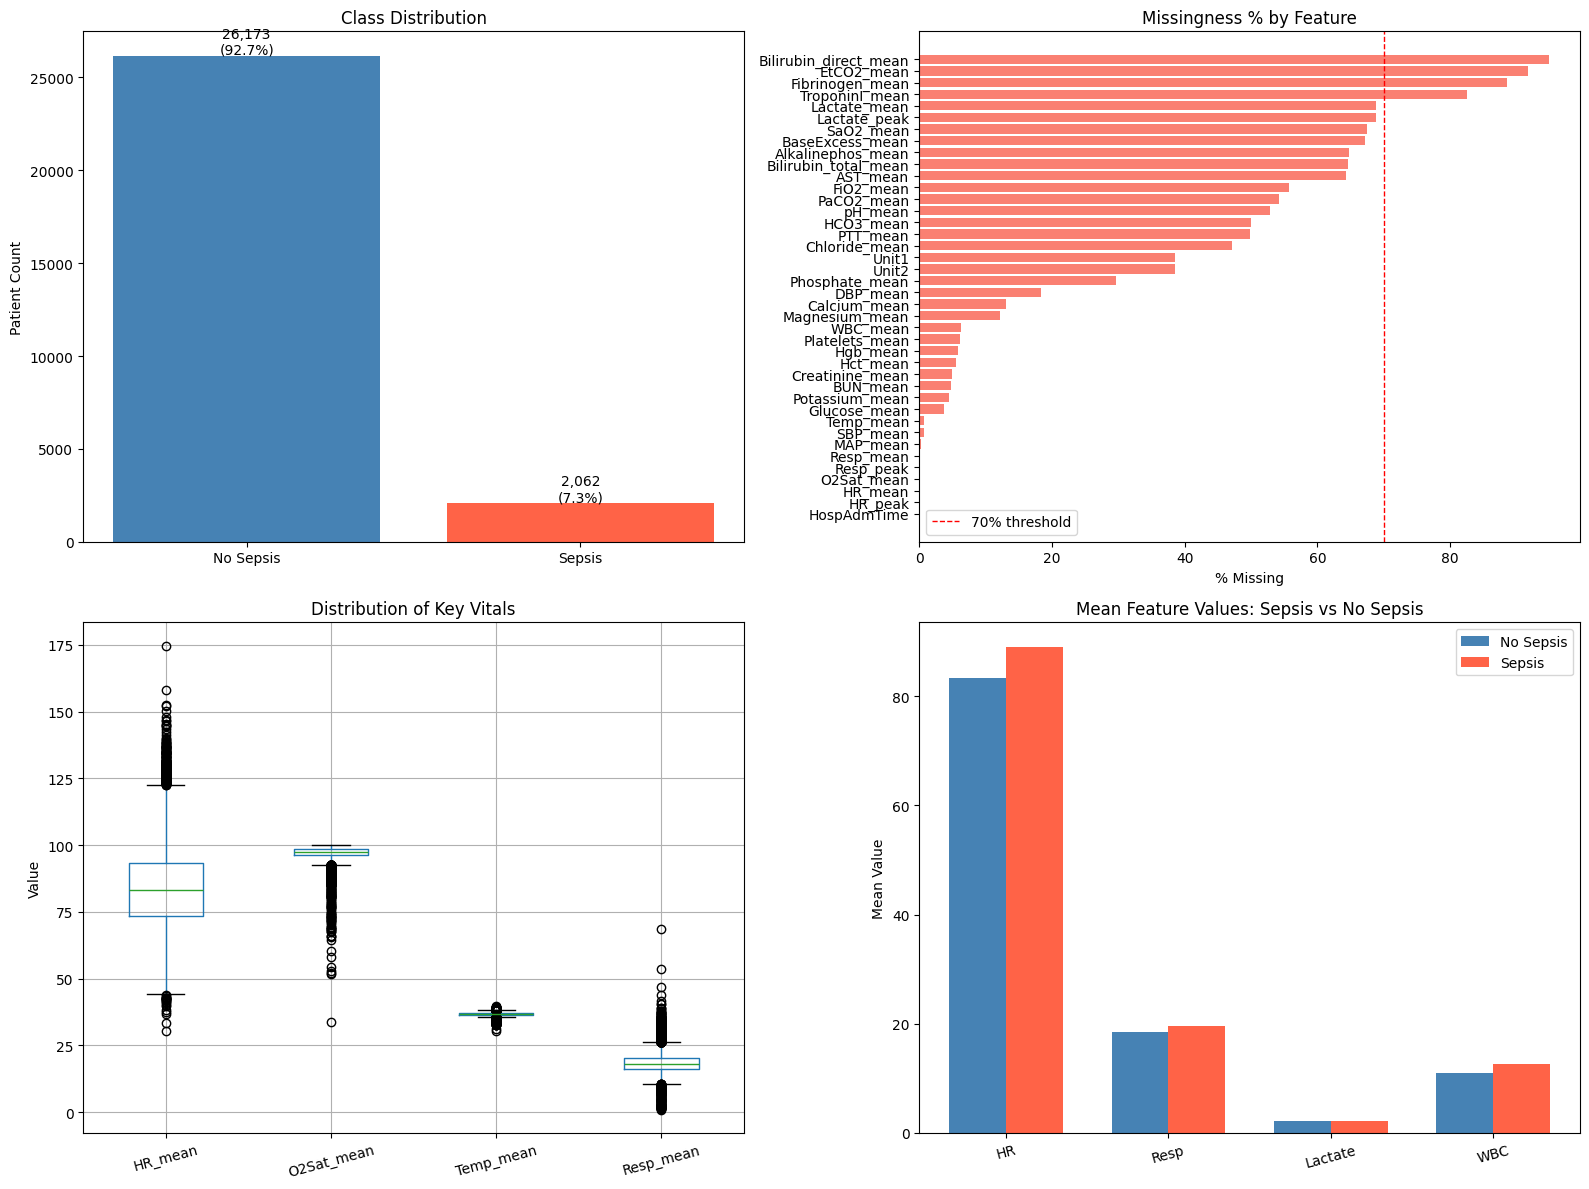

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Class imbalance bar chart
ax = axes[0, 0]
counts = df_agg['Sepsis'].value_counts()
ax.bar(['No Sepsis', 'Sepsis'], counts.values, color=['steelblue', 'tomato'])
ax.set_title('Class Distribution')
ax.set_ylabel('Patient Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, f'{v:,}\n({v/len(df_agg)*100:.1f}%)', ha='center')

# 2. Missingness heatmap
ax = axes[0, 1]
missing = (df_agg.isnull().sum() / len(df_agg) * 100).sort_values(ascending=False)
missing = missing[missing > 0]
ax.barh(missing.index, missing.values, color='salmon')
ax.set_title('Missingness % by Feature')
ax.set_xlabel('% Missing')
ax.invert_yaxis()
ax.axvline(x=70, color='red', linestyle='--', linewidth=1, label='70% threshold')
ax.legend()

# 3. Key vitals distributions
ax = axes[1, 0]
vitals = ['HR_mean', 'O2Sat_mean', 'Temp_mean', 'Resp_mean']
df_agg[vitals].boxplot(ax=ax)
ax.set_title('Distribution of Key Vitals')
ax.set_ylabel('Value')
ax.tick_params(axis='x', rotation=15)

# 4. Sepsis vs non-sepsis — key features
ax = axes[1, 1]
sepsis_yes = df_agg[df_agg['Sepsis'] == 1]
sepsis_no = df_agg[df_agg['Sepsis'] == 0]
features = ['HR_mean', 'Resp_mean', 'Lactate_mean', 'WBC_mean']
means_yes = sepsis_yes[features].mean()
means_no = sepsis_no[features].mean()
x = np.arange(len(features))
width = 0.35
ax.bar(x - width/2, means_no.values, width, label='No Sepsis', color='steelblue')
ax.bar(x + width/2, means_yes.values, width, label='Sepsis', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(['HR', 'Resp', 'Lactate', 'WBC'], rotation=15)
ax.set_title('Mean Feature Values: Sepsis vs No Sepsis')
ax.set_ylabel('Mean Value')
ax.legend()

plt.tight_layout()
plt.show()

## EDA Overview — Key Findings

**Class Imbalance**
The dataset is heavily imbalanced — 92.7% of patients (26,173) never developed
sepsis, with only 7.3% (2,062) classified as septic. This imbalance motivates the use of SMOTE during preprocessing and warrants
careful choice of evaluation metrics. Accuracy alone would be misleading
given that a model predicting no sepsis for every patient would still achieve
92.7% accuracy.

**Missingness**
Missingness varies dramatically across features. High-MNAR lab features
(Bilirubin_direct, EtCO2, Fibrinogen, TroponinI) exceed 80% missingness —
these are only ordered when clinically suspected, meaning their absence is
itself informative. Four features exceed the 70% threshold, and several
mid-range labs (Lactate, SaO2, BaseExcess) fall between 60-70%. Vitals
are near-complete at under 1% missing. All remaining missingness was
handled via median imputation after train/test splitting.

**Mean Feature Values: Sepsis vs No Sepsis**
Sepsis patients show notably higher mean HR compared to non-sepsis patients,
consistent with tachycardia as a primary sepsis indicator. Resp and WBC
are modestly elevated in sepsis patients. Lactate means are similar across
classes, though this is likely dampened by high missingness concentrating
observations toward lower baseline values.

**Distribution of Key Vitals**
HR shows the widest spread and most outliers of the four core vitals,
suggesting high variability across patients. O2Sat is tightly clustered
near 97-98% for most patients. Temp and Resp are relatively compact
distributions with few extreme outliers, indicating these vitals are
generally well-controlled in the ICU setting.

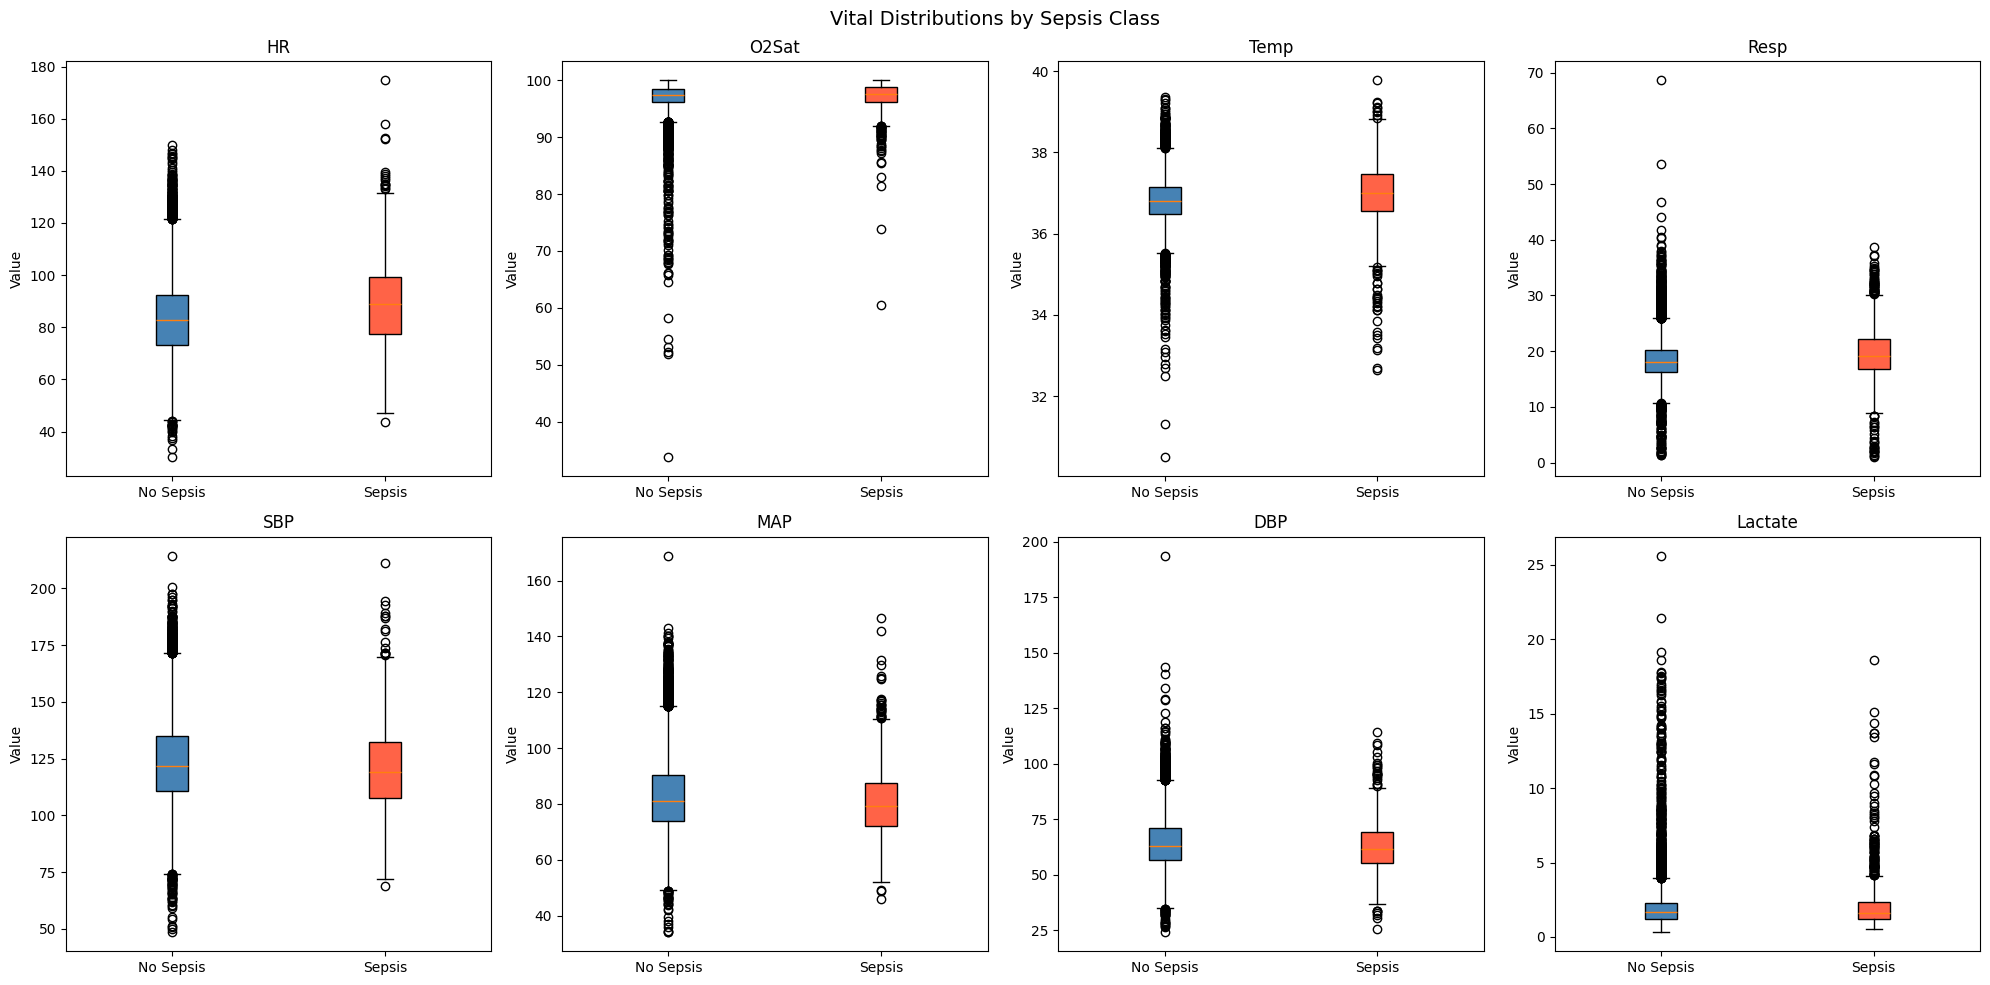

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

vitals = ['HR_mean', 'O2Sat_mean', 'Temp_mean', 'Resp_mean',
          'SBP_mean', 'MAP_mean', 'DBP_mean', 'Lactate_mean']

for ax, col in zip(axes.flatten(), vitals):
    data = [df_agg[df_agg['Sepsis'] == 0][col].dropna(),
            df_agg[df_agg['Sepsis'] == 1][col].dropna()]

    bp = ax.boxplot(data, labels=['No Sepsis', 'Sepsis'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    ax.set_title(col.replace('_mean', ''))
    ax.set_ylabel('Value')

plt.suptitle('Vital Distributions by Sepsis Class', fontsize=14)
plt.tight_layout()
plt.show()

## Vital Distributions by Sepsis Class

Boxplots of key vital signs stratified by sepsis status reveal several
clinically meaningful patterns:

**HR (Heart Rate)** — sepsis patients exhibit a higher median heart rate
and wider spread, consistent with tachycardia as a hallmark sepsis symptom.

**Resp (Respiration Rate)** — a clear upward shift in median respiration
rate among sepsis patients, reflecting the increased respiratory demand
associated with systemic infection.

**Temp (Temperature)** — sepsis patients skew slightly higher, consistent
with fever as a common sepsis presentation, though class overlap is substantial.

**SBP, MAP, DBP (Blood Pressure)** — distributions are nearly identical
across classes, suggesting blood pressure measures alone are weak
discriminators for sepsis in this dataset.

**O2Sat (Oxygen Saturation)** — minimal difference between classes, with
both tightly clustered near 97-98%. Not expected to be a strong predictor.

**Lactate** — median values are similar across classes, but sepsis patients
show more extreme high-value outliers. Elevated lactate is a key clinical
marker of sepsis severity, though its signal here is concentrated in the tail
rather than the central distribution — likely a consequence of high missingness
(~69%) limiting the sample.

Overall, HR and Resp show the clearest distributional separation between
classes and are expected to be among the more important features during
classification.

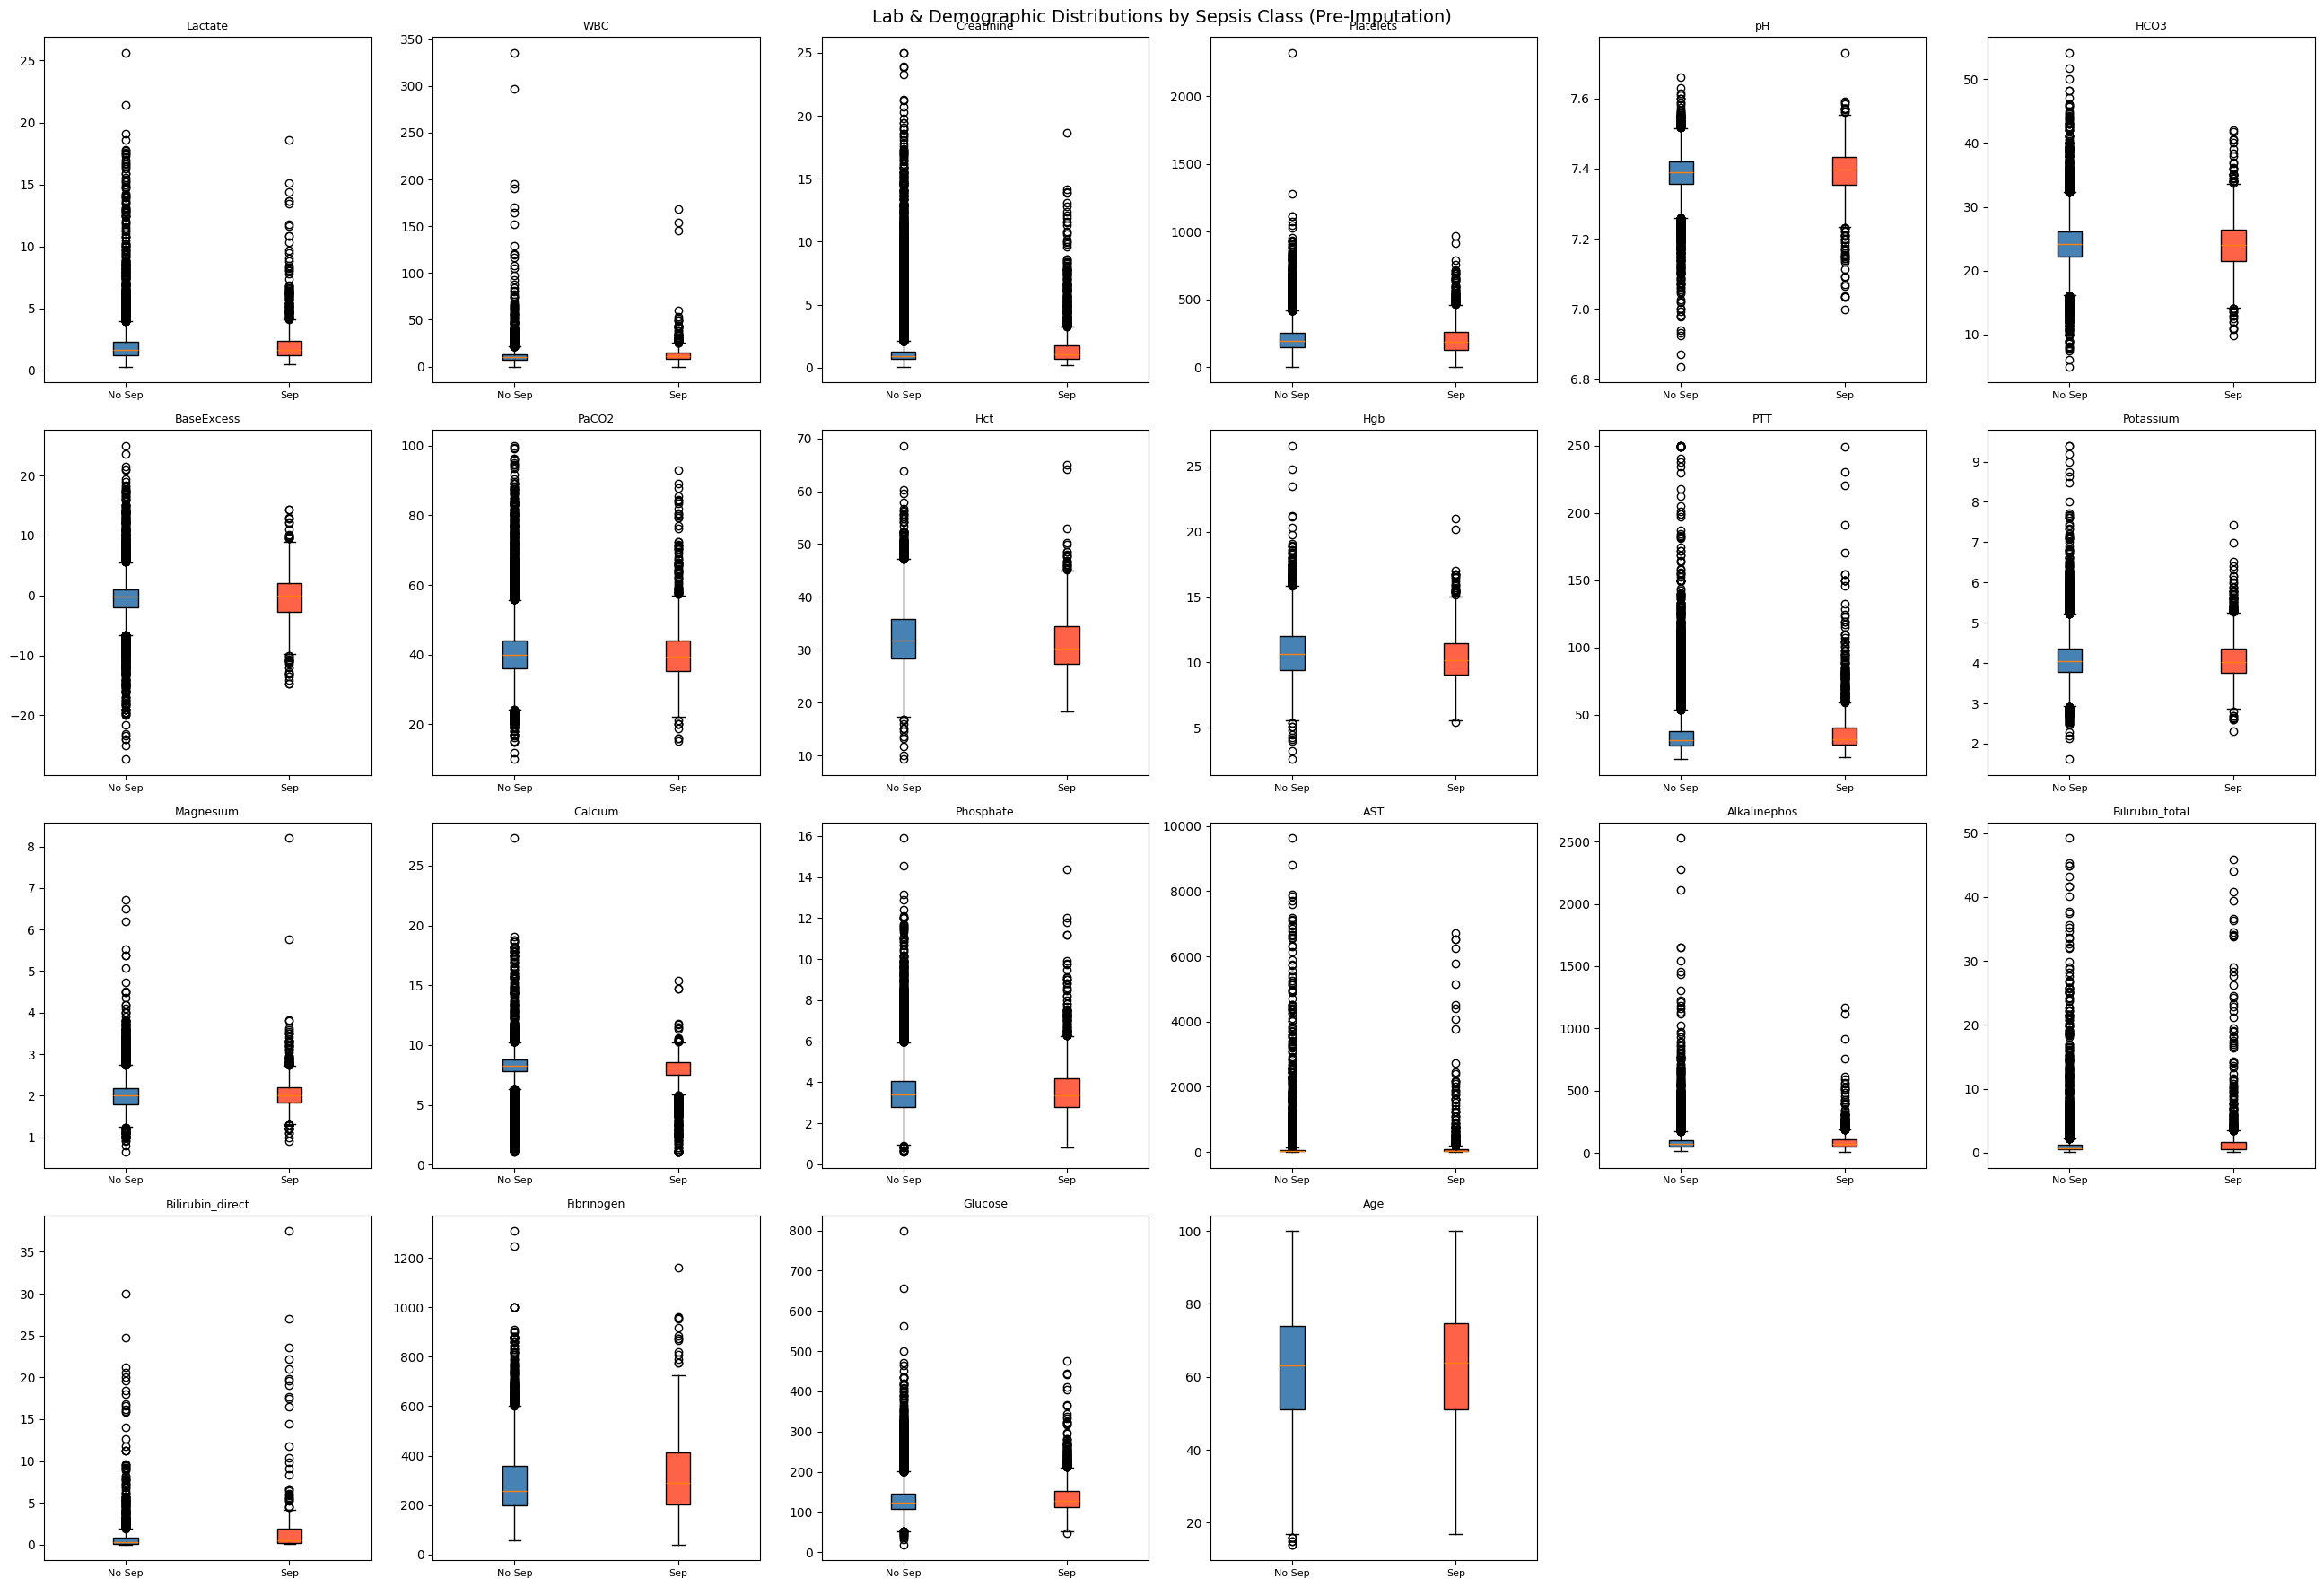

In [ ]:
fig, axes = plt.subplots(4, 6, figsize=(26, 18))

features = [
    # Key sepsis labs
    'Lactate_mean', 'WBC_mean', 'Creatinine_mean', 'Platelets_mean',
    # Acid-base
    'pH_mean', 'HCO3_mean', 'BaseExcess_mean', 'PaCO2_mean',
    # Blood / coagulation
    'Hct_mean', 'Hgb_mean', 'PTT_mean',
    # Electrolytes
    'Potassium_mean', 'Magnesium_mean', 'Calcium_mean', 'Phosphate_mean',
    # Liver / organ dysfunction
    'AST_mean', 'Alkalinephos_mean', 'Bilirubin_total_mean', 'Bilirubin_direct_mean',
    # Other labs
    'Fibrinogen_mean', 'Glucose_mean',
    # Demographics
    'Age'
]

for ax, col in zip(axes.flatten(), features):
    data = [df_agg[df_agg['Sepsis'] == 0][col].dropna(),
            df_agg[df_agg['Sepsis'] == 1][col].dropna()]
    bp = ax.boxplot(data, labels=['No Sep', 'Sep'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    ax.set_title(col.replace('_mean', ''), fontsize=9)
    ax.tick_params(axis='x', labelsize=8)

# Hide unused axes
for ax in axes.flatten()[len(features):]:
    ax.set_visible(False)

plt.suptitle('Lab & Demographic Distributions by Sepsis Class (Pre-Imputation)', fontsize=14)
plt.tight_layout()
plt.show()

## Lab & Demographic Distributions by Sepsis Class

**Strong class separation — useful predictors:**

Lactate — sepsis patients show more high-value outliers, consistent with
tissue hypoperfusion. Signal concentrated in the tail due to ~69% missingness.

pH and BaseExcess — sepsis patients have notably lower median pH and more
negative BaseExcess, consistent with metabolic acidosis as a hallmark of
septic shock. These are among the clearest separating features in the dataset.

Phosphate — higher median in sepsis patients, consistent with kidney
dysfunction and impaired phosphate excretion.

Platelets — lower median in sepsis patients, consistent with
thrombocytopenia as a common sepsis complication and a component of
the SOFA severity score.

Fibrinogen — sepsis patients show a notably higher median, consistent
with fibrinogen being an acute phase protein that rises during infection.
Clinically meaningful despite high missingness (~88%).

Age — sepsis patients are older on average, confirming the well-established
clinical finding that older patients are significantly more susceptible
to sepsis.

**Moderate or ambiguous separation:**

Glucose — sepsis patients skew slightly higher, consistent with stress
hyperglycemia, though overlap between classes is substantial.

WBC — modest elevation in sepsis patients reflecting immune response,
though extreme outliers compress the visible distribution.

PTT — slight differences between classes, relevant as a coagulation
marker in severe sepsis and DIC, but overlap is high.

**Weak or no separation — limited predictive value:**

Hct and Hgb — nearly identical distributions across classes, confirming
these are weak individual predictors of sepsis. Their near-perfect
collinearity with each other also limits their combined contribution.

Magnesium and Calcium — very similar distributions across classes.
Electrolyte abnormalities in sepsis are non-specific and likely
secondary to other organ dysfunction.

AST, Alkalinephos, Bilirubin_direct, Bilirubin_total — extreme outliers
dominate the scale, making distributions difficult to interpret visually.
High missingness (>60%) further limits the signal available from these
liver dysfunction markers.

**Overall:** pH, BaseExcess, Platelets, Fibrinogen, and Age show the
clearest distributional separation between sepsis and non-sepsis patients.
Combined with HR and Resp from the vitals analysis, these features are
expected to contribute most during classification. Lasso regularization
will confirm which features survive formal feature selection.

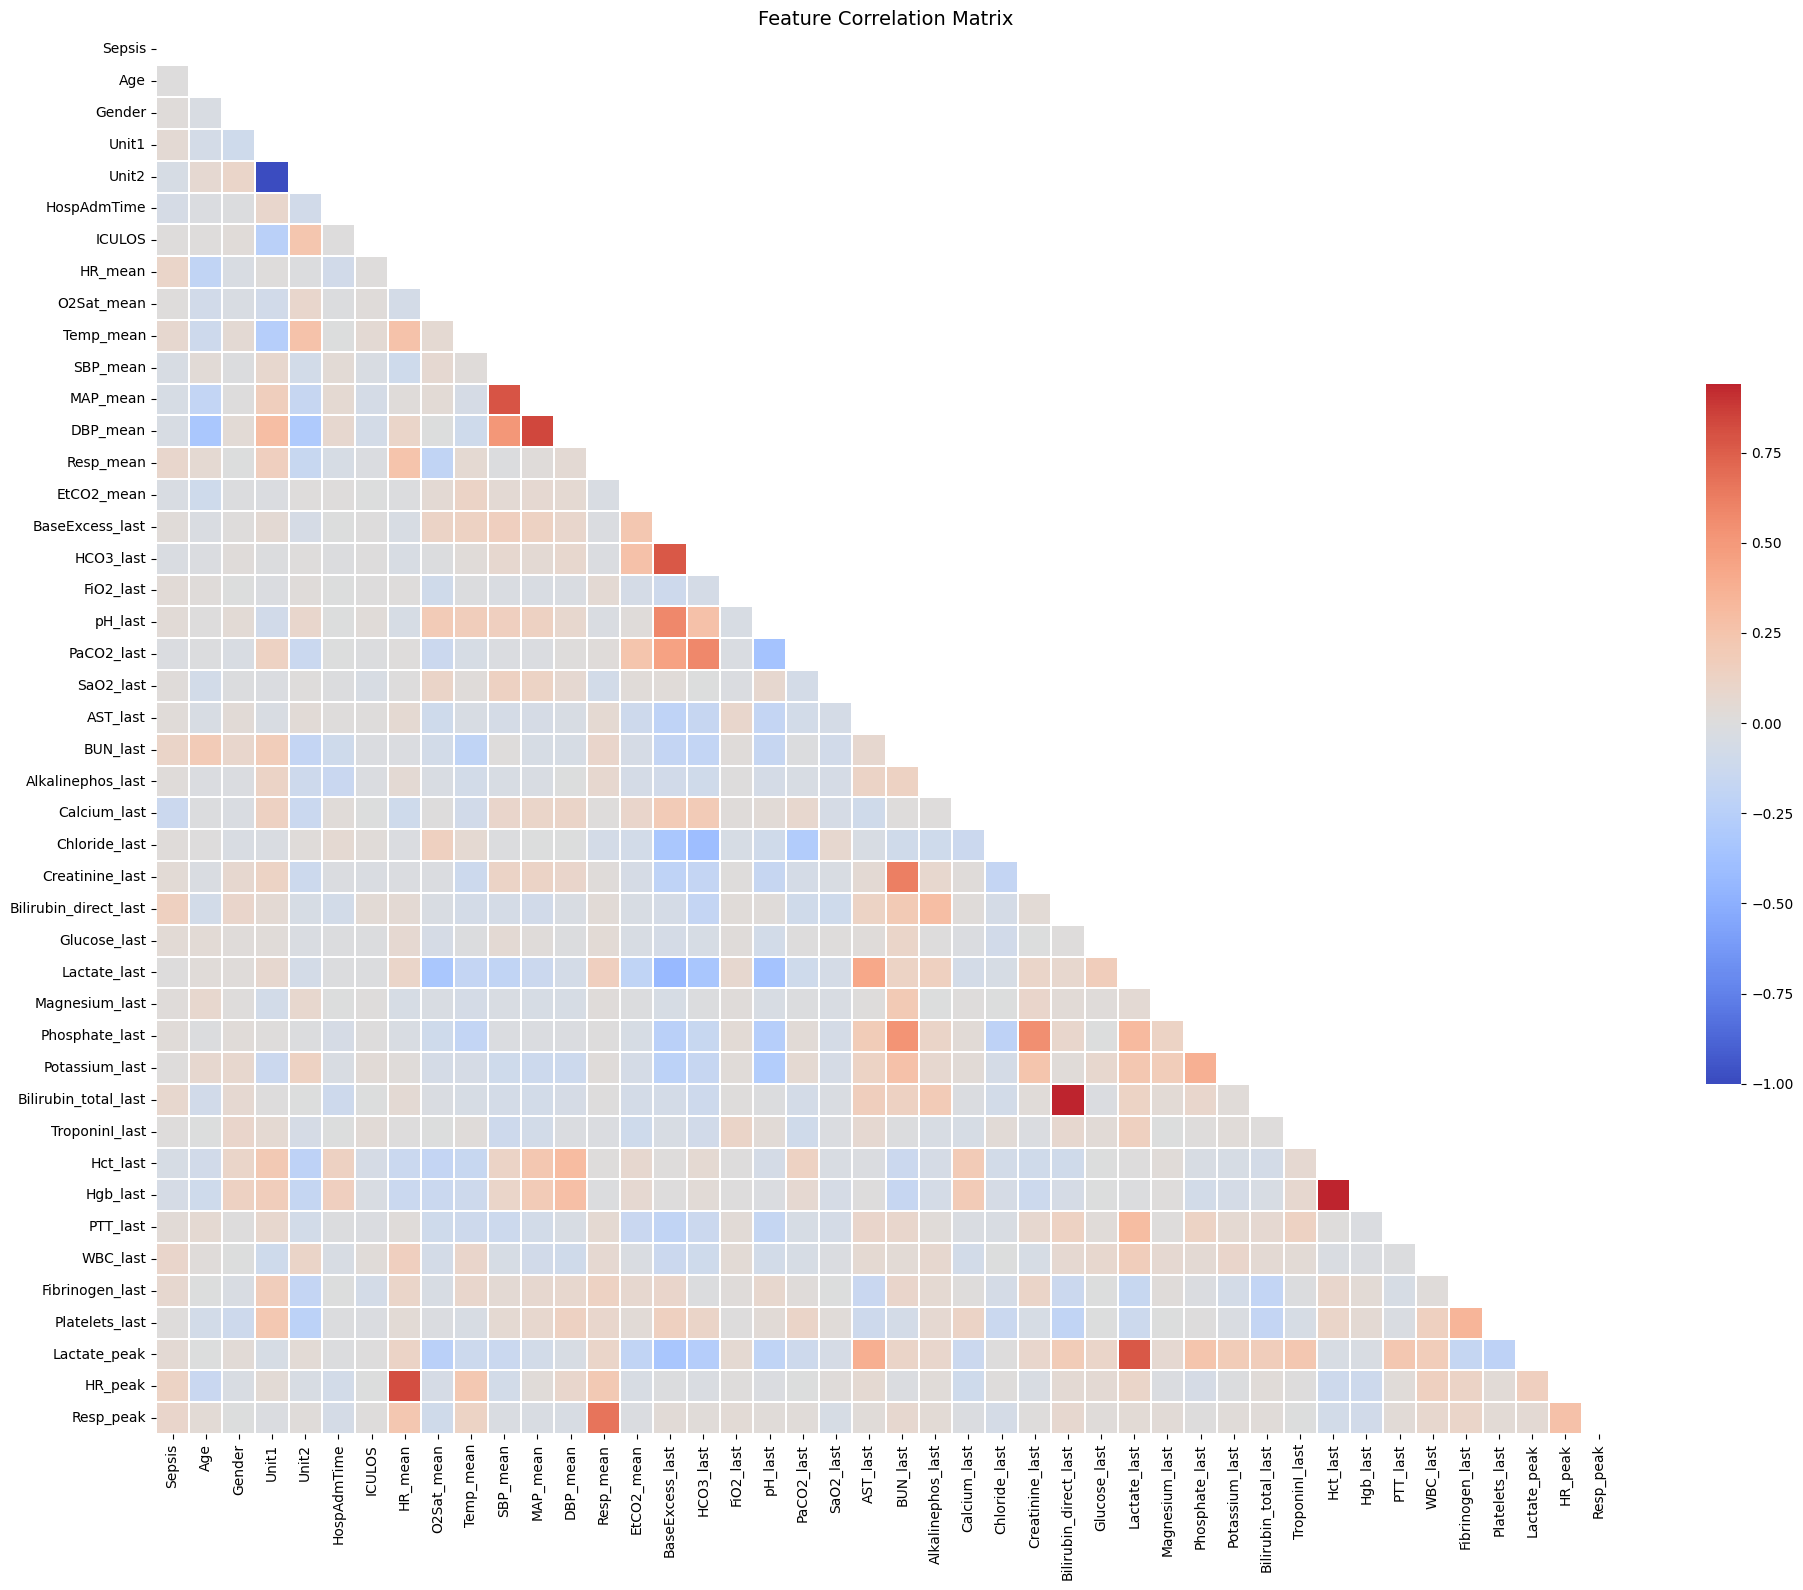

In [ ]:
# Correlation heatmap (numeric features only, excluding patient ID)
fig, ax = plt.subplots(figsize=(20, 16))
corr = df_agg.drop(columns=['patient']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.5})
ax.set_title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

## Multicollinearity Observations

From the correlation heatmap, most feature pairs show weak correlations,
suggesting the dataset does not suffer from severe multicollinearity overall.
However, several notable pairs warrant attention:

**Hct & Hgb** are the most strongly correlated pair in the matrix. Both measure
red blood cell concentration and are clinically redundant. Lasso regularization
will likely eliminate one during feature selection.

**Lactate_last & Lactate_peak** are highly correlated by construction since both
are derived from the same variable. Lactate_peak is retained as the preferred
feature given its clinical relevance as a severity indicator.

**SBP_mean, MAP_mean, DBP_mean** form a correlated cluster of blood pressure
measures. MAP is mathematically derived from SBP and DBP, making this
correlation expected. Lasso should reduce this cluster effectively.

**BaseExcess_last, HCO3_last, pH_last** are correlated acid-base markers,
standard in ICU data and clinically expected.

**BUN_last & Creatinine_last** show mild positive correlation as kidney
function markers, consistent with clinical expectations.

High-missingness labs (Bilirubin_direct, TroponinI, EtCO2) show weak
correlations throughout — these should be interpreted cautiously given
>80% missingness. These variables are likely MNAR: values are only ordered
when clinically suspected, meaning their absence is itself informative.

Additionally, engineered features representing different aggregations of the
same underlying variable (e.g. HR_mean and HR_peak) are correlated by
construction. Lasso regularization is the primary mechanism for resolving
this redundancy during feature selection.





In [ ]:
# Define features and target — drop patient ID (not a feature) and target
X = df_agg.drop(columns=['patient', 'Sepsis'])
y = df_agg['Sepsis']

# Stratified 80/20 split on patient level — preserves ~7.3% sepsis rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.value_counts(normalize=True).round(3)

((22588, 43),
 (5647, 43),
 Sepsis
 0.0    0.927
 1.0    0.073
 Name: proportion, dtype: float64)

In [ ]:
# Median imputation — fit on training set only, transform both
# Prevents any test set information leaking into the imputer
imputer = SimpleImputer(strategy='median')

X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Confirm no missing values remain
X_train_imp.isnull().sum().sum(), X_test_imp.isnull().sum().sum()

(np.int64(0), np.int64(0))

In [ ]:
# Fit scaler on training set only, transform both
# Critical for LDA, KNN, and regularized Logit — less so for Naive Bayes and QDA
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_train_imp.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X_test_imp.columns)

# Confirm scaling worked — training set should have mean ~0 and std ~1
X_train_scaled.mean().round(2).head(), X_train_scaled.std().round(2).head()

(Age            0.0
 Gender         0.0
 Unit1         -0.0
 Unit2          0.0
 HospAdmTime   -0.0
 dtype: float64,
 Age            1.0
 Gender         1.0
 Unit1          1.0
 Unit2          1.0
 HospAdmTime    1.0
 dtype: float64)

In [ ]:
# Apply SMOTE to training set only — never to test set
# Oversamples the minority class (Sepsis=1) to balance training data
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Confirm class balance after SMOTE
X_train_res.shape, pd.Series(y_train_res).value_counts()

((41876, 43),
 Sepsis
 0.0    20938
 1.0    20938
 Name: count, dtype: int64)

## SMOTE — Synthetic Minority Oversampling Technique

The training dataset is heavily imbalanced — approximately 92.7% of patients
never developed sepsis, with only 7.3% classified as septic. Training a
classifier on imbalanced data leads to biased predictions toward the majority
class, producing models that effectively ignore the minority class entirely.

SMOTE addresses this by synthetically generating new minority class observations.
Rather than simply duplicating existing sepsis cases, SMOTE creates new synthetic
patients by interpolating between existing sepsis patients and their nearest
neighbors in feature space. This produces plausible but novel examples that
help the classifier learn the boundaries of the sepsis class more effectively.

After applying SMOTE, the training set is balanced at 50/50 (20,938 sepsis
and 20,938 non-sepsis patients), giving classifiers equal exposure to both
classes during training. Importantly, SMOTE is applied to the training set
only — the test set retains the original class distribution to reflect
real-world conditions and ensure unbiased evaluation.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

# Lasso logistic regression — C is inverse of regularization strength
# Lower C = stronger regularization = more features zeroed out
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42, max_iter=1000)
lasso.fit(X_train_res, y_train_res)

# Get surviving features (non-zero coefficients)
feature_names = X_train_res.columns
lasso_coefs = pd.Series(lasso.coef_[0], index=feature_names)

# Show all coefficients sorted by absolute value
lasso_coefs_sorted = lasso_coefs.reindex(lasso_coefs.abs().sort_values(ascending=False).index)
lasso_coefs_sorted

,0
Lactate_peak,3.794652e-01
HR_peak,3.680076e-01
Hgb_mean,-3.158643e-01
Hct_mean,3.089604e-01
BUN_mean,3.043052e-01
Lactate_mean,-2.851293e-01
Temp_mean,2.472381e-01
O2Sat_mean,2.468572e-01
Potassium_mean,-2.055021e-01
Resp_mean,1.967129e-01


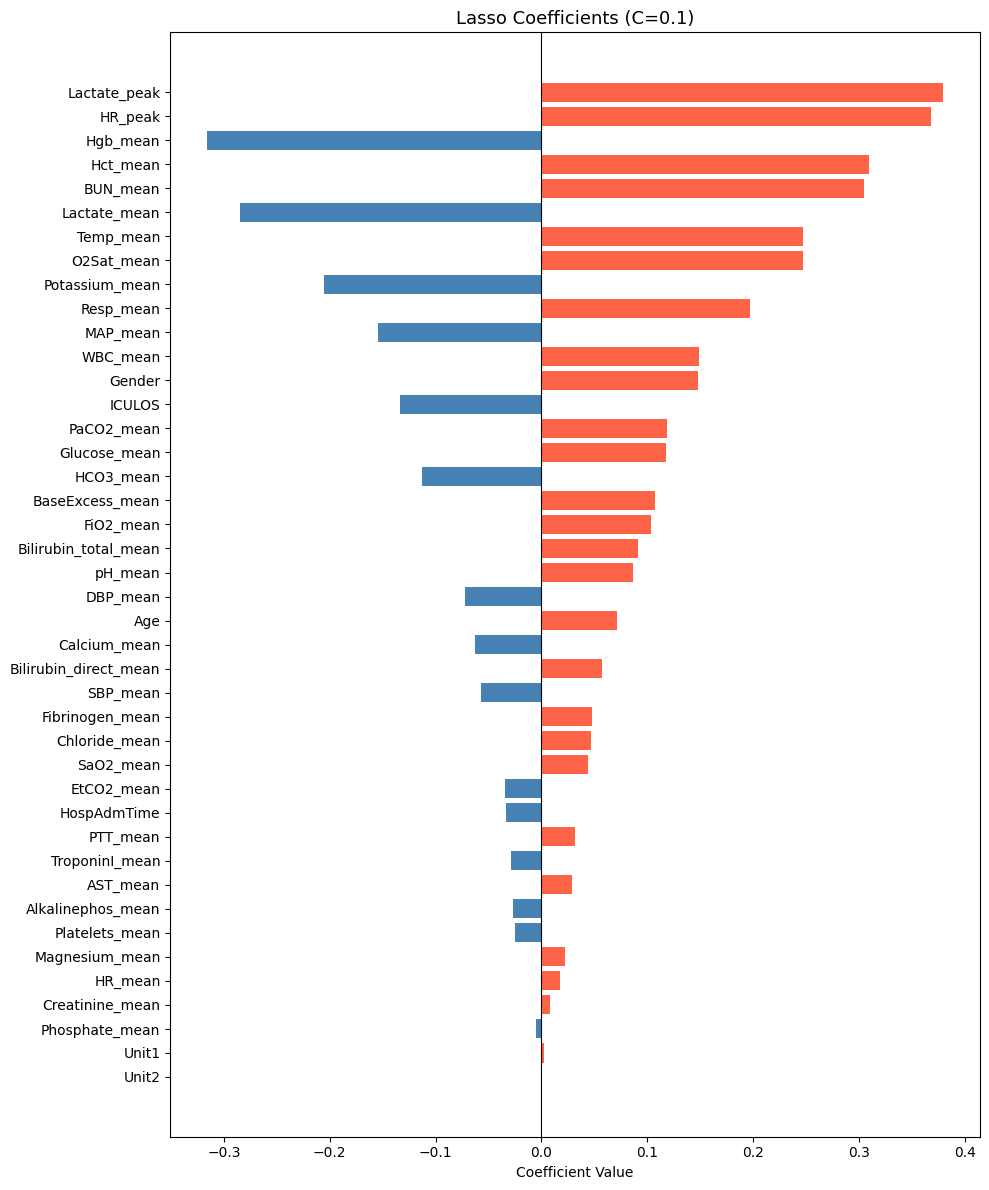

In [ ]:
fig, ax = plt.subplots(figsize=(10, 12))

# Plot non-zero coefficients only
nonzero = lasso_coefs_sorted[lasso_coefs_sorted != 0]
colors = ['tomato' if c > 0 else 'steelblue' for c in nonzero.values]

ax.barh(nonzero.index, nonzero.values, color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Lasso Coefficients (C=0.1)', fontsize=13)
ax.set_xlabel('Coefficient Value')
ax.invert_yaxis()

plt.tight_layout()
plt.show()